In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Preparing the data

In [2]:
# Read all the data 
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')
gender = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")

In [3]:
# Get the first 5 rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Get the first 5 rows
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# Get the first 5 rows
gender.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [6]:
# The number of rows and coulmns
gender.shape

(418, 2)

In [7]:
# The number of rows and coulmns
train.shape, test.shape

((891, 12), (418, 11))

In [8]:
# Data info and data types
print("Training data")
train.info()
print("\nTest Data")
test.info()

Training data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Test Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null

In [9]:
# Missing value for each column
print('Missing values in train columns:')
train.isnull().sum()

Missing values in train columns:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# Missing value for each column
print('Missing values in test columns:')
test.isnull().sum()

Missing values in test columns:


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [11]:
# Merge the data to clean it up
merged = pd.merge(test, gender, on="PassengerId")
merged.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1


<blockquote><p style="font-size:16px; color:#159364; font-family:verdana;">Merge the test and gender data on <code>PassengerId</code>.</p></blockquote>

In [12]:
merged.shape

(418, 12)

In [13]:
# Concatenate the merged data and trained one to start cleaning
concat = pd.concat([train, merged])
concat.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<blockquote><p style="font-size:16px; color:#159364; font-family:verdana;">Concatenate the data with train data to start cleaning and visulaization phases.</p></blockquote>

In [14]:
concat.shape

(1309, 12)

In [15]:
# Missing values in all columns
print('Missing values on all data: ')
concat.isnull().sum()

Missing values on all data: 


PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

# Data Pre-processing

## Handeling the missing values

In [16]:
# number of values to get the mode 
concat['Embarked'].value_counts()

S    914
C    270
Q    123
Name: Embarked, dtype: int64

<blockquote><p style="font-size:16px; color:#159364; font-family:verdana;">We can fill the <code>Embarked</code> missing with the mode value <code>S</code>.</p></blockquote>

In [17]:
concat['Embarked'].fillna('S',inplace=True)
train['Embarked'].fillna('S',inplace=True)
test['Embarked'].fillna('S',inplace=True)

In [18]:
# Number of missing data
print('Missing values on all data: ')
concat.isnull().sum()

Missing values on all data: 


PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          0
dtype: int64

In [19]:
# Statistical meaning for the data
concat.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.377387,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.484918,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [20]:
# fill with median 
concat['Fare'].fillna(concat['Fare'].median(),inplace=True)
train['Fare'].fillna(train['Fare'].median(),inplace=True)
test['Fare'].fillna(test['Fare'].median(),inplace=True)

In [21]:
# apply lambda function to strip title and group them based on titles
concat["title"] = concat['Name'].apply(lambda x: x.split(','))
concat["title"] = concat["title"].apply(lambda x: x[-1].split('.')[0].strip())

train["title"] = train['Name'].apply(lambda x: x.split(','))
train["title"] = train["title"].apply(lambda x: x[-1].split('.')[0].strip())

test["title"] = test['Name'].apply(lambda x: x.split(','))
test["title"] = test["title"].apply(lambda x: x[-1].split('.')[0].strip())

In [22]:
concat

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Dona
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Mr


In [23]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [24]:
# Number of titles
concat['title'].value_counts()

Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Mlle              2
Major             2
Ms                2
Lady              1
Sir               1
Mme               1
Don               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: title, dtype: int64

In [25]:
concat[concat['title'] == 'Mr'].mean()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


PassengerId    659.554822
Survived         0.107001
Pclass           2.381770
Age             32.252151
SibSp            0.282695
Parch            0.159841
Fare            24.782523
dtype: float64

In [26]:
# Replace each title with an appropriate abbreviation
concat['title'] = concat['title'].replace(['the Countess','Dr','Jonkheer','Master','Mlle','Mile','Mme','Ms','Rev'],'Other')
concat['title'] = concat['title'].replace(['Don','Sir','Capt','Col','Lady','Major','Dona'],'Old') 

train['title'] = train['title'].replace(['the Countess','Dr','Jonkheer','Master','Mlle','Mile','Mme','Ms','Rev'],'Other')
train['title'] = train['title'].replace(['Don','Sir','Capt','Col','Lady','Major','Dona'],'Old') 

test['title'] = test['title'].replace(['the Countess','Dr','Jonkheer','Master','Mlle','Mile','Mme','Ms','Rev'],'Other')
test['title'] = test['title'].replace(['Don','Sir','Capt','Col','Lady','Major','Dona'],'Old') 


In [27]:
concat

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Old
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Mr


In [28]:
concat['title'].value_counts()

Mr       757
Miss     260
Mrs      197
Other     84
Old       11
Name: title, dtype: int64

In [29]:
# Make sure male and female titles are correct
pd.crosstab(train['title'],train['Sex'])

Sex,female,male
title,,
Miss,182,0
Mr,0,517
Mrs,125,0
Old,1,7
Other,6,53


In [30]:
# Grouped dataframe
grouped = train.groupby(['title'])
print(grouped.mean())

       PassengerId  Survived    Pclass        Age     SibSp     Parch  \
title                                                                   
Miss    408.884615  0.697802  2.307692  21.773973  0.714286  0.549451   
Mr      454.499033  0.156673  2.410058  32.368090  0.288201  0.152805   
Mrs     453.160000  0.792000  2.000000  35.898148  0.696000  0.832000   
Old     533.000000  0.500000  1.000000  52.500000  0.375000  0.125000   
Other   459.050847  0.525424  2.254237  15.679074  1.644068  0.949153   

            Fare  
title             
Miss   43.797873  
Mr     24.441560  
Mrs    45.138533  
Old    39.293750  
Other  36.098024  


In [31]:
grouped.describe().T.style.background_gradient()

In [32]:
grouped.corr().style.background_gradient()

In [33]:
concat['Age']=concat['Age'].fillna(grouped['Age'].transform('mean'))
train['Age']=train['Age'].fillna(grouped['Age'].transform('mean'))
test['Age']=test['Age'].fillna(grouped['Age'].transform('mean'))

In [34]:
concat['Age'] = concat['Age'].astype('int64')
train['Age'] = train['Age'].astype('int64')
test['Age'] = test['Age'].astype('int64')

In [35]:
concat.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   int64  
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1309 non-null   object 
 12  title        1309 non-null   object 
dtypes: float64(1), int64(6), object(6)
memory usage: 143.2+ KB


In [36]:
concat.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
title             0
dtype: int64

In [37]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
title            0
dtype: int64

In [38]:
concat['Cabin'].value_counts()

C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
C22 C26            4
F33                4
                  ..
A14                1
E63                1
E12                1
E38                1
C105               1
Name: Cabin, Length: 186, dtype: int64

<blockquote><p style="font-size:16px; color:#159364; font-family:verdana;">The <code>Cabin</code> has a lot of null values and not so much meaning the decision will be to drop it .</p></blockquote>

# Data Visualization

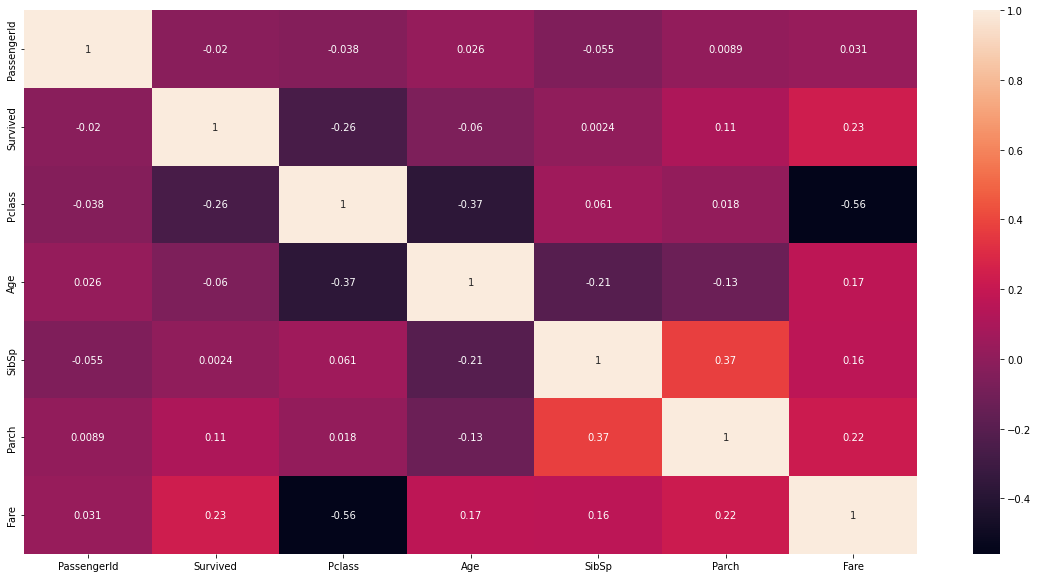

In [39]:
# Correlation matrix
plt.figure(figsize=(20,10))
sns.heatmap(concat.corr(), annot=True)
plt.show()

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp; Not so much correlation here but the highest in negative correlation will be <code>Fare - Pclass</code>, <code>Age - Pclass</code> and with positive will be <code>SibSp - Parch</code>
</div>


[Text(0.5, 1.0, 'Survived Passengers based on sex')]

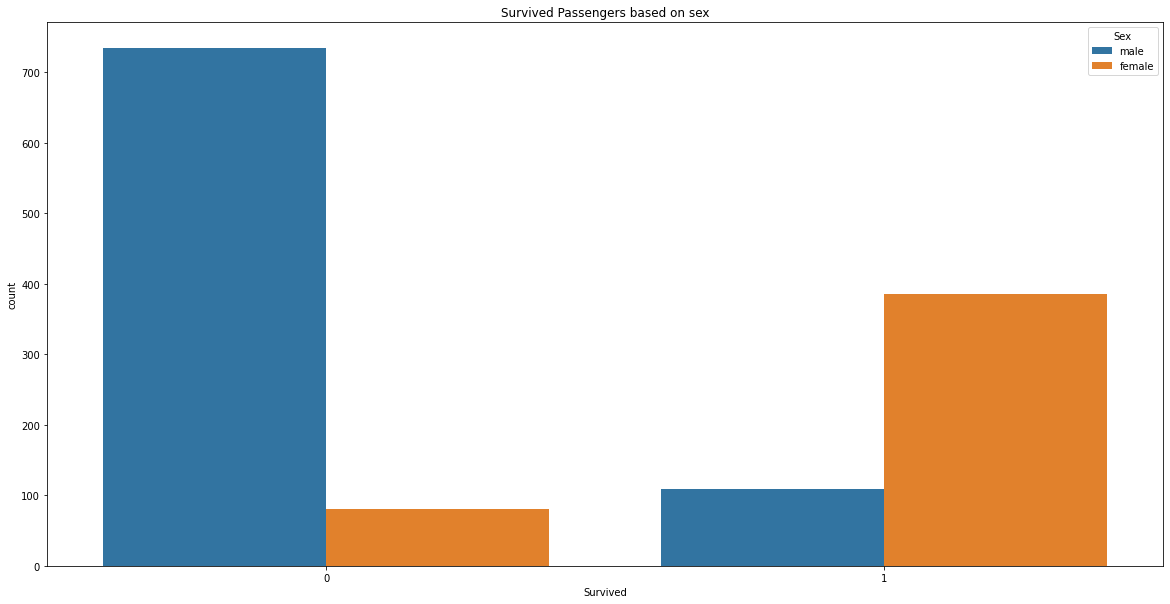

In [40]:
# Countplot for survival sex
plt.figure(figsize=(20,10))
sns.countplot(x='Survived', data=concat, hue='Sex').set(title='Survived Passengers based on sex')

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp; <code>Female</code> is the most survived other than males.
</div>

[Text(0.5, 1.0, 'Survived Passengers based on Pclass')]

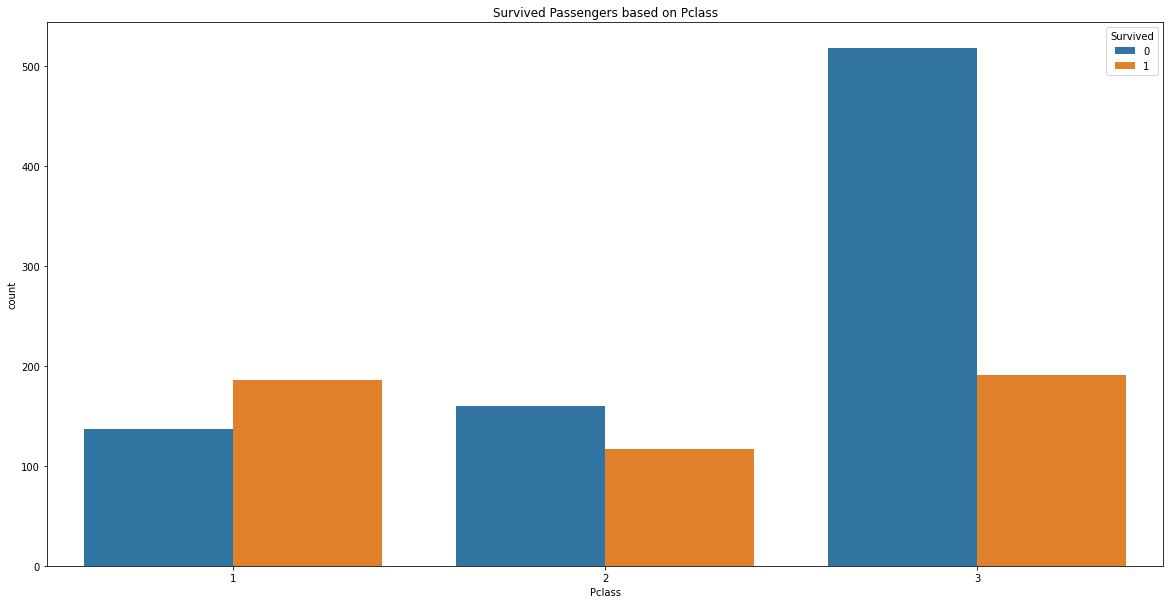

In [41]:
# Countplot for survival Pclass
plt.figure(figsize=(20,10))
sns.countplot(x='Pclass', data=concat, hue='Survived').set(title='Survived Passengers based on Pclass')

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp; <code>third Pclass</code> is the most died ones.
</div>


[Text(0.5, 1.0, 'Survived Passengers based on Embarked')]

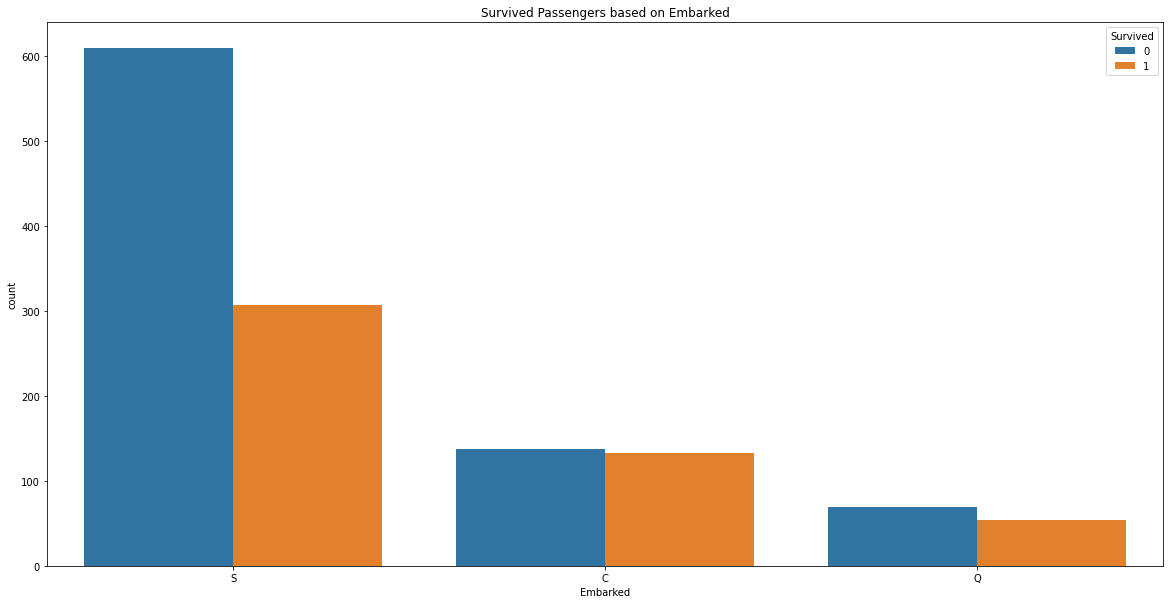

In [42]:
# Countplot for survival Embarked
plt.figure(figsize=(20,10))
sns.countplot(x='Embarked', data=concat, hue='Survived').set(title='Survived Passengers based on Embarked')

<AxesSubplot:xlabel='Embarked', ylabel='count'>

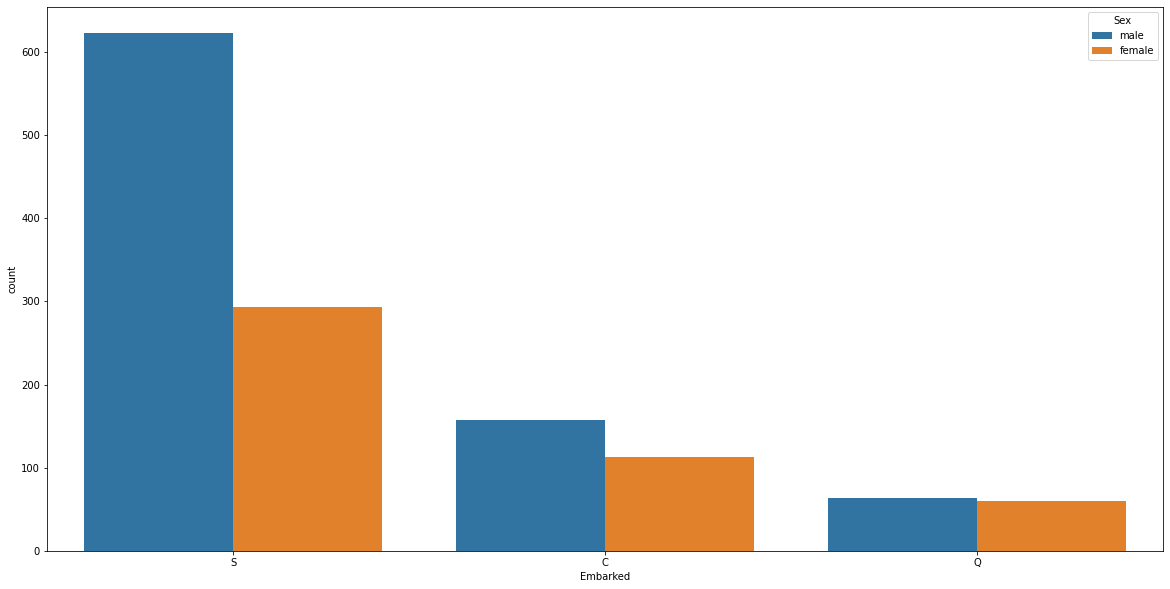

In [43]:
# Countplot for sex survival Embarked
plt.figure(figsize=(20,10))
sns.countplot(x='Embarked', hue='Sex', data = concat)

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp; <code>Female S Embarked</code> is the most died ones.
</div>


<AxesSubplot:xlabel='Embarked', ylabel='Survived'>

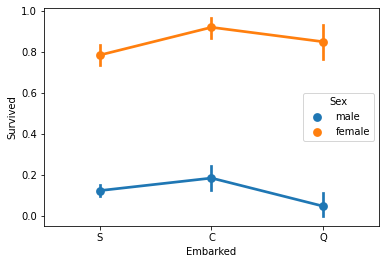

In [44]:
sns.pointplot(x='Embarked', y='Survived', hue='Sex', data=concat)

# Modeling

In [45]:
# Converting categorical variables to numeric
train['Sex']=train['Sex'].map({'male': 0,'female': 1})
train['Embarked']=train['Embarked'].map({'S': 0,'C': 1,'Q':2})
train['title']=train['title'].map({'Miss':0,'Mr': 1,'Mrs': 2,'Old':3,'Other':4})

# Converting categorical variables to numeric
test['Sex']=test['Sex'].map({'male': 0,'female': 1})
test['Embarked']=test['Embarked'].map({'S': 0,'C': 1,'Q':2})
test['title']=test['title'].map({'Miss':0,'Mr': 1,'Mrs': 2,'Old':3,'Other':4})

In [46]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    int64  
 12  title        891 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 90.6+ KB


In [47]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
title            0
dtype: int64

In [48]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,NaN,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,C85,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,NaN,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,C123,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27,0,0,211536,13.0000,NaN,0,4
887,888,1,1,"Graham, Miss. Margaret Edith",1,19,0,0,112053,30.0000,B42,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,21,1,2,W./C. 6607,23.4500,NaN,0,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26,0,0,111369,30.0000,C148,1,1


In [49]:
train.drop(['Cabin'], axis=1, inplace=True)

In [50]:
# for training 
X = train[['Pclass','Sex','Age','Fare','title']]
y = train['Survived']

In [51]:
# for testing 
X_test = test[['Pclass','Sex','Age','Fare','title']]

In [52]:
X_test.shape

(418, 5)

In [53]:
from sklearn.model_selection import train_test_split 

X_train_, X_test_, y_train_, y_test_  = train_test_split(X, y, test_size=0.3, random_state=42)

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc


The Support Vector Machine accuracy score is 0.65

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.94      0.76       157
           1       0.74      0.25      0.38       111

    accuracy                           0.65       268
   macro avg       0.69      0.59      0.57       268
weighted avg       0.68      0.65      0.60       268

The Confusion Matrix:
 [[147  10]
 [ 83  28]]


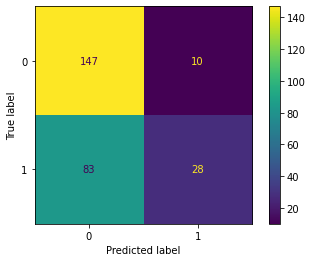

In [55]:
svm = SVC()
svm.fit(X_train_, y_train_)
svm_score = svm.score(X_test_, y_test_)
print('\nThe Support Vector Machine accuracy score is {:03.2f}\n'.format(svm_score))
y_pred = svm.predict(X_test_)
print("Classification Report:\n", classification_report(y_test_, y_pred))
print("The Confusion Matrix:\n",confusion_matrix(y_test_, y_pred))
cm = confusion_matrix(y_test_, y_pred, labels=svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot()
plt.show()


The KNN accuracy score is 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       157
           1       0.80      0.74      0.77       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.81       268
weighted avg       0.81      0.81      0.81       268

The Confusion Matrix:
 [[136  21]
 [ 29  82]]


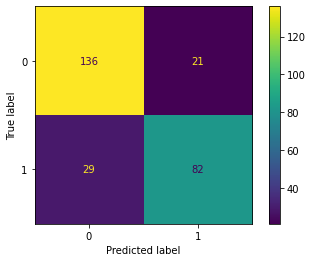

In [56]:
knn = KNeighborsClassifier()
knn.fit(X_test_, y_test_)
knn_score = knn.score(X_test_, y_test_)
print('\nThe KNN accuracy score is {:03.2f}\n'.format(knn_score))
y_pred = knn.predict(X_test_)
print("Classification Report:\n", classification_report(y_test_, y_pred))
print("The Confusion Matrix:\n",confusion_matrix(y_test_, y_pred))
cm = confusion_matrix(y_test_, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot()
plt.show()


The Support Vector Machine accuracy score is 0.80

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       157
           1       0.78      0.72      0.75       111

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268

The Confusion Matrix:
 [[134  23]
 [ 31  80]]


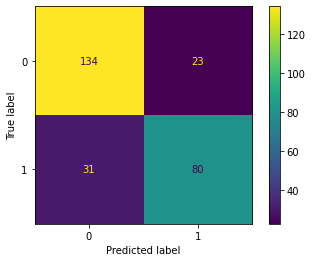

In [57]:
rfc = RandomForestClassifier()
rfc.fit(X_train_, y_train_)
rfc_score = rfc.score(X_test_, y_test_)
print('\nThe Support Vector Machine accuracy score is {:03.2f}\n'.format(rfc_score))
y_pred = rfc.predict(X_test_)
print("Classification Report:\n", classification_report(y_test_, y_pred))
print("The Confusion Matrix:\n",confusion_matrix(y_test_, y_pred))
cm = confusion_matrix(y_test_, y_pred, labels=rfc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_)
disp.plot()
plt.show()


The Logistic Regression accuracy score is 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       157
           1       0.77      0.71      0.74       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268

The Confusion Matrix:
 [[133  24]
 [ 32  79]]


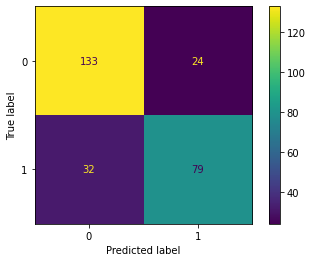

In [58]:
lr = LogisticRegression()
lr.fit(X_train_, y_train_)
lr_score = lr.score(X_test_, y_test_)
print('\nThe Logistic Regression accuracy score is {:03.2f}\n'.format(lr_score))
y_pred = lr.predict(X_test_)
print("Classification Report:\n", classification_report(y_test_, y_pred))
print("The Confusion Matrix:\n",confusion_matrix(y_test_, y_pred))
cm = confusion_matrix(y_test_, y_pred, labels=lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot()
plt.show()


The XGB Classifier accuracy score is 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85       157
           1       0.79      0.76      0.77       111

    accuracy                           0.82       268
   macro avg       0.81      0.81      0.81       268
weighted avg       0.82      0.82      0.82       268

The Confusion Matrix:
 [[135  22]
 [ 27  84]]


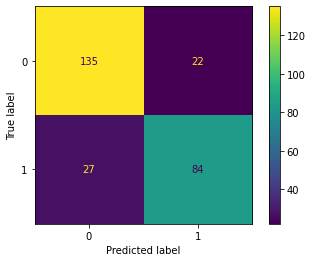

In [59]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_, y_train_)
xgb_score = xgb.score(X_test_, y_test_)
print('\nThe XGB Classifier accuracy score is {:03.2f}\n'.format(xgb_score))
y_pred = xgb.predict(X_test_)
print("Classification Report:\n", classification_report(y_test_, y_pred))
print("The Confusion Matrix:\n",confusion_matrix(y_test_, y_pred))
cm = confusion_matrix(y_test_, y_pred, labels=xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot()
plt.show()

In [60]:
print(y_pred)

[1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 0 1 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0
 1 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1
 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 1 1 0 1 0 0 0 0 0]


In [61]:
from sklearn.model_selection import cross_val_score
scoreCV2=cross_val_score(xgb,X,y,cv=10)
print(scoreCV2)


[0.76666667 0.86516854 0.73033708 0.80898876 0.87640449 0.85393258
 0.85393258 0.78651685 0.83146067 0.82022472]


In [62]:
predictions=xgb.predict(X_test)
print(predictions)

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0 1 0
 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0
 0 1 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 1 1 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1
 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 0 1 0
 0 1 0 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 0 1 0 0 1 0 0 0]


In [63]:
X_test.shape

(418, 5)

In [64]:
submission= pd.DataFrame({"PassengerId":test["PassengerId"],"Survived":predictions})
submission.to_csv('submission.csv', index=False)
submission=pd.read_csv('submission.csv')
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [65]:
output = pd.DataFrame({'PassengerId': test.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("PassengerId data frame created")

PassengerId data frame created
